# Sparse Matrix Solver Experiments

Benchmarking linear system solvers (Matrix Inverse, LU, Cholesky, QR, Sparse LU) across matrix types: dense, SPD, sparse, tridiagonal, and Gershgorin.

In [168]:
import time
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.sparse
import scipy.sparse.linalg


## Solvers

In [169]:
def solve_matrix_inverse(A, b):
    return np.linalg.inv(A) @ b


def solve_lu(A, b):
    lu, piv = scipy.linalg.lu_factor(A)
    return scipy.linalg.lu_solve((lu, piv), b)


def solve_cholesky(A, b) :
    A_sym = (A + A.T) / 2
    c, low = scipy.linalg.cho_factor(A_sym)
    return scipy.linalg.cho_solve((c, low), b)


def solve_qr(A, b) :
    Q, R = np.linalg.qr(A)
    return np.linalg.solve(R, Q.T @ b)


def solve_sparse_lu(A, b) :
    return scipy.sparse.linalg.spsolve(scipy.sparse.csc_matrix(A), b)


def run_benchmark(fn, methods, realisations, max_iterations, target_seconds=0.3, *args, **kwargs):
    records = []

    for _ in range(realisations):
        A, b = fn(*args, **kwargs)

        for name, solver in methods.items():
            solver(A, b)
            t_single = time.perf_counter()
            solver(A, b)
            t_single = time.perf_counter() - t_single

            n_iters = max(1, min(max_iterations, int(target_seconds / t_single)))

            t = 0.0
            for _ in range(n_iters):
                t0 = time.perf_counter()
                solver(A, b)
                t += time.perf_counter() - t0

            records.append({
                "Method": name,
                "ExecutionTime": t / n_iters
            })

    return pl.DataFrame(records)


## Matrix Generators

In [170]:
def generate_general_dense(n):
    A = np.random.randn(n, n) + 5*np.eye(n)
    b = np.random.randn(n)
    return A, b

def generate_symmetric(n):
    M = np.random.randn(n, n)
    A = M.T @ M + np.eye(n)
    b = np.random.uniform(-15, 15, n)
    return A, b

def generate_tridiagonal(n):
    A = np.diag(2*np.ones(n)) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1)
    b = np.random.randn(n)
    return A, b

In [171]:
def generate_sparse(n, rho, a=5.0, delta=0.01, b_density=None):
    if rho < 1 / n:
        raise ValueError(f"rho must be >= 1/n for invertibility (rho={rho}, 1/n={1/n:.4f})")

    num_offdiag = int(rho * n * n - n)

    diag_flat = np.arange(n) * (n + 1)
    offdiag_flat = np.delete(np.arange(n * n), diag_flat)

    A = np.zeros((n, n))
    if num_offdiag > 0:
        chosen = np.random.choice(offdiag_flat, size=num_offdiag, replace=False)
        rows, cols = np.unravel_index(chosen, (n, n))
        A[rows, cols] = np.random.uniform(-a, a, num_offdiag)

    row_sums = np.abs(A).sum(axis=1)
    np.fill_diagonal(A, row_sums + np.random.uniform(delta, 1, n))

    if b_density is None:
        b_density = rho
    if not (0 <= b_density <= 1):
        raise ValueError(f"b_density must be in [0, 1], got {b_density}")

    num_nonzero_b = int(b_density * n)
    b = np.zeros(n)
    if num_nonzero_b > 0:
        idx = np.random.choice(n, size=num_nonzero_b, replace=False)
        b[idx] = np.random.uniform(-a, a, num_nonzero_b)

    return A, b


def generate_gershgorin(n, target_density):
    num_offdiag = max(0, min(int(target_density * n * n) - n, n * (n - 1)))

    diag_flat = np.arange(n) * (n + 1)
    offdiag_flat = np.delete(np.arange(n * n), diag_flat)
    chosen = np.random.choice(offdiag_flat, size=num_offdiag, replace=False)
    rows, cols = np.unravel_index(chosen, (n, n))

    A = np.zeros((n, n))
    A[rows, cols] = np.random.uniform(-10, 10, num_offdiag)

    row_sums = np.abs(A).sum(axis=1)
    np.fill_diagonal(A, row_sums + np.random.uniform(0.01, 1, n))

    return A, np.random.randn(n)



## Experiment Definitions

In [172]:
REALISATIONS = 5
MAX_ITERATIONS = 100

METHODS_DENSE   = {"MatrixInverse": solve_matrix_inverse, "LU": solve_lu, "QR": solve_qr}
METHODS_SPD     = {"MatrixInverse": solve_matrix_inverse, "LU": solve_lu, "Cholesky": solve_cholesky, "QR": solve_qr}
METHODS_SPARSE  = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "QR": solve_qr, "MatrixInverse": solve_matrix_inverse}
METHODS_SPARSE4 = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "QR": solve_qr}
METHODS_ALL     = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "Cholesky": solve_cholesky, "MatrixInverse": solve_matrix_inverse, "QR": solve_qr}
METHODS_SPARSE6 = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "Cholesky": solve_cholesky}


def experiment_1_dense(n: int) :
    return run_benchmark(generate_general_dense, METHODS_DENSE, REALISATIONS, MAX_ITERATIONS, n=n)


def experiment_2_symmetric(n: int) :
    return run_benchmark(generate_symmetric, METHODS_SPD, REALISATIONS, MAX_ITERATIONS, n=n)


def experiment_3_sparse_dense_b(n: int, density: float) :
    return run_benchmark(generate_sparse, METHODS_SPARSE, REALISATIONS, MAX_ITERATIONS, n=n, rho=density, b_density=1.0)


def experiment_4_sparse_both(n: int, density: float) :
    return run_benchmark(generate_sparse, METHODS_SPARSE4, REALISATIONS, MAX_ITERATIONS, n=n, rho=density, b_density=density)


def experiment_5_dense_b(n: int, matrix_type: str) :
    if matrix_type == "tridiagonal":
        return run_benchmark(generate_tridiagonal, METHODS_ALL, REALISATIONS, MAX_ITERATIONS, n=n)
    density = (3 * n - 2) / (n ** 2)
    return run_benchmark(generate_gershgorin, METHODS_ALL, REALISATIONS, MAX_ITERATIONS, n=n, target_density=density)


def experiment_6_sparse_b(n: int, matrix_type: str) :
    b_density = (3 * n - 2) / (n ** 2)
    num_nonzero_b = max(1, int(b_density * n))

    def _with_sparse_b(generator, **kw):
        def _gen(n):
            A, _ = generator(n=n, **kw)
            idx = np.random.choice(n, size=num_nonzero_b, replace=False)
            b = np.zeros(n)
            b[idx] = np.random.randn(num_nonzero_b)
            return A, b
        return _gen

    if matrix_type == "tridiagonal":
        fn = _with_sparse_b(generate_tridiagonal)
    else:
        density = (3 * n - 2) / (n ** 2)
        fn = _with_sparse_b(generate_gershgorin, target_density=density)

    return run_benchmark(fn, METHODS_SPARSE6, REALISATIONS, MAX_ITERATIONS, n=n)


## Experiment Runners

In [173]:
def run_experiment_1_2():
    print("Experiments 1 & 2: Dense and SPD matrices")
    dimensions = [50, 100, 200, 400]
    frames = []

    for d in dimensions:
        print(f"  n={d}")

        df1 = experiment_1_dense(d)
        df1 = df1.with_columns(
            pl.lit(d).alias("Dimension"),
            pl.lit("General Dense").alias("MatrixType"),
            pl.lit("Exp1: Dense").alias("Experiment"),
            pl.lit(1.0).alias("Density"),
        )
        frames.append(df1)

        df2 = experiment_2_symmetric(d)
        df2 = df2.with_columns(
            pl.lit(d).alias("Dimension"),
            pl.lit("SPD").alias("MatrixType"),
            pl.lit("Exp2: SPD").alias("Experiment"),
            pl.lit(1.0).alias("Density"),
        )
        frames.append(df2)

    return pl.concat(frames)

In [174]:
def run_experiment_3():
    print("Experiment 3: Sparse A, dense b")
    densities = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
    n = 200
    frames = []

    for rho in densities:
        print(f"  rho={rho:.2f}")

        df = experiment_3_sparse_dense_b(n, rho).with_columns(
            pl.lit(n).alias("Dimension"),
            pl.lit("Sparse").alias("MatrixType"),
            pl.lit("Exp3: Sparse A, Dense b").alias("Experiment"),
            pl.lit(rho).alias("Density"),
        )

        frames.append(df)

    return pl.concat(frames)


In [175]:
def run_experiment_4():
    print("Experiment 4: Sparse A, sparse b")
    densities = [0.01, 0.05, 0.1, 0.2, 0.5]
    n = 200
    frames = []

    for rho in densities:
        print(f"  rho={rho:.2f}")

        df = experiment_4_sparse_both(n, rho).with_columns(
            pl.lit(n).alias("Dimension"),
            pl.lit("Sparse").alias("MatrixType"),
            pl.lit("Exp4: Sparse A, Sparse b").alias("Experiment"),
            pl.lit(rho).alias("Density")
        )

        frames.append(df)

    return pl.concat(frames)


In [176]:
def run_experiment_5():
    print("Experiment 5: Tridiagonal and Gershgorin (dense b)")
    dimensions = [100, 200, 400, 800]
    frames = []

    for n in dimensions:
        print(f"  n={n}")
        density = (3*n - 2) / (n**2)

        for mtype in ("tridiagonal", "gershgorin"):
            df = experiment_5_dense_b(n, mtype).with_columns(
                pl.lit(n).alias("Dimension"),
                pl.lit(density).alias("Density"),
                pl.lit(mtype.capitalize()).alias("MatrixType"),
                pl.lit("Exp5: Dense b").alias("Experiment")
            )
            frames.append(df)

    return pl.concat(frames)

def run_experiment_6():
    print("Experiment 6: Tridiagonal and Gershgorin (sparse b)")
    dimensions = [100, 200, 400, 800]
    frames = []

    for n in dimensions:
        print(f"  n={n}")
        density = (3*n - 2) / (n**2)

        for mtype in ("tridiagonal", "gershgorin"):
            df = experiment_6_sparse_b(n, mtype).with_columns(
                pl.lit(n).alias("Dimension"),
                pl.lit(density).alias("Density"),
                pl.lit(mtype.capitalize()).alias("MatrixType"),
                pl.lit("Exp6: Sparse b").alias("Experiment")
            )
            frames.append(df)

    return pl.concat(frames)



## Plotting

In [177]:
def _errorbar_grouped(ax, data: pl.DataFrame, x_col: str, hue_col: str, **kwargs):
    """Plot mean ± std errorbar lines, one per unique value of hue_col."""

    # unique hue values (preserve first-seen order)
    hue_values = data.get_column(hue_col).unique(maintain_order=True).to_list()

    for label in hue_values:
        subset = data.filter(pl.col(hue_col) == label)

        grouped = (
            subset
            .group_by(x_col)
            .agg([
                pl.col("ExecutionTime").mean().alias("Mean"),
                pl.col("ExecutionTime").std().alias("Std"),
            ])
            .sort(x_col)
        )

        ax.errorbar(
            grouped.get_column(x_col).to_numpy(),
            grouped.get_column("Mean").to_numpy(),
            yerr=grouped.get_column("Std").to_numpy(),
            label=str(label),
            capsize=4,
            alpha=0.8,
            **kwargs,
        )

def create_plots(results: pl.DataFrame, save_dir: str = "plots"):
    Path(save_dir).mkdir(exist_ok=True)

    def _log_axes(ax, xlabel, ylabel, title):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Execution time (s)")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # ---------- Exp 1 & 2 ----------
    exp1_2 = results.filter(pl.col("Experiment").is_in(["Exp1: Dense", "Exp2: SPD"]))
    if exp1_2.height > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, exp_name in zip(axes, ["Exp1: Dense", "Exp2: SPD"]):
            df_exp = exp1_2.filter(pl.col("Experiment") == exp_name)
            _errorbar_grouped(ax, df_exp, x_col="Dimension", hue_col="Method", marker="o")
            _log_axes(ax, "Matrix dimension", "Execution time (s)", exp_name)
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp1_2_time_vs_size.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # ---------- Exp 3 ----------
    exp3 = results.filter(pl.col("Experiment") == "Exp3: Sparse A, Dense b")
    if exp3.height > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        _errorbar_grouped(ax, exp3, x_col="Density", hue_col="Method", marker="s")
        _log_axes(ax, "Matrix density", "Execution time (s)", "Exp3: Sparse A, Dense b")
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp3_time_vs_density.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # ---------- Exp 3 & 4 comparison ----------
    exp4 = results.filter(pl.col("Experiment") == "Exp4: Sparse A, Sparse b")
    if exp3.height > 0 and exp4.height > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))



## Summary Statistics

In [178]:
def compute_stats(results):
    return (
        results
        .groupby(["Experiment", "Method", "Dimension"], as_index=False)["ExecutionTime"]
        .agg(
            MeanTime="mean",
            StdTime="std",
            MinTime="min",
            MaxTime="max",
            Samples="count",
        )
    )



def print_summary_statistics(results):
    # get unique experiments in first-seen order
    experiments = results.get_column("Experiment").unique(maintain_order=True)

    for exp in experiments:
        print(f"\n{exp}:")
        
        # filter by experiment
        stats = (
            results
            .filter(pl.col("Experiment") == exp)
            .group_by("Method")
            .agg([
                pl.col("ExecutionTime").mean().alias("MeanTime"),
                pl.col("ExecutionTime").std().alias("StdTime"),
                pl.col("Dimension").mean().alias("AvgDim"),
                pl.len().alias("Samples"),
            ])
            .sort("MeanTime")
        )

        # iterate through rows
        for row in stats.to_dicts():
            print(
                f"  {row['Method']:15s}: {row['MeanTime']:.6f} ± {row['StdTime']:.6f} s"
                f"  (n={row['Samples']}, avg dim={row['AvgDim']:.0f})"
            )

## Run Experiments

In [179]:
Path("results").mkdir(exist_ok=True)
Path("plots").mkdir(exist_ok=True)

experiments_to_run = [
    ("1 & 2", run_experiment_1_2),
    ("3",     run_experiment_3),
    ("4",     run_experiment_4),
    # ("5",  run_experiment_5),
    # ("6",  run_experiment_6),
]

all_results = []
for name, fn in experiments_to_run:
    result = fn()
    all_results.append(result)
    print(f"  -> {len(result)} records")

combined_results = pl.concat(all_results)


Experiments 1 & 2: Dense and SPD matrices
  n=50
  n=100
  n=200
  n=400
  -> 140 records
Experiment 3: Sparse A, dense b
  rho=0.01
  rho=0.05
  rho=0.10
  rho=0.20
  rho=0.50
  rho=0.80
  rho=1.00
  -> 140 records
Experiment 4: Sparse A, sparse b
  rho=0.01
  rho=0.05
  rho=0.10
  rho=0.20
  rho=0.50
  -> 75 records


In [180]:
print_summary_statistics(combined_results)



Exp1: Dense:
  LU             : 0.000750 ± 0.000935 s  (n=20, avg dim=188)
  MatrixInverse  : 0.001742 ± 0.002388 s  (n=20, avg dim=188)
  QR             : 0.005258 ± 0.007593 s  (n=20, avg dim=188)

Exp2: SPD:
  LU             : 0.000604 ± 0.000783 s  (n=20, avg dim=188)
  Cholesky       : 0.000909 ± 0.001264 s  (n=20, avg dim=188)
  MatrixInverse  : 0.001595 ± 0.002263 s  (n=20, avg dim=188)
  QR             : 0.003743 ± 0.004700 s  (n=20, avg dim=188)

Exp3: Sparse A, Dense b:
  LU             : 0.000482 ± 0.001111 s  (n=35, avg dim=200)
  MatrixInverse  : 0.000603 ± 0.000145 s  (n=35, avg dim=200)
  QR             : 0.001754 ± 0.000499 s  (n=35, avg dim=200)
  SparseLU       : 0.002934 ± 0.001091 s  (n=35, avg dim=200)

Exp4: Sparse A, Sparse b:
  LU             : 0.000267 ± 0.000059 s  (n=25, avg dim=200)
  QR             : 0.001629 ± 0.000406 s  (n=25, avg dim=200)
  SparseLU       : 0.002417 ± 0.000792 s  (n=25, avg dim=200)


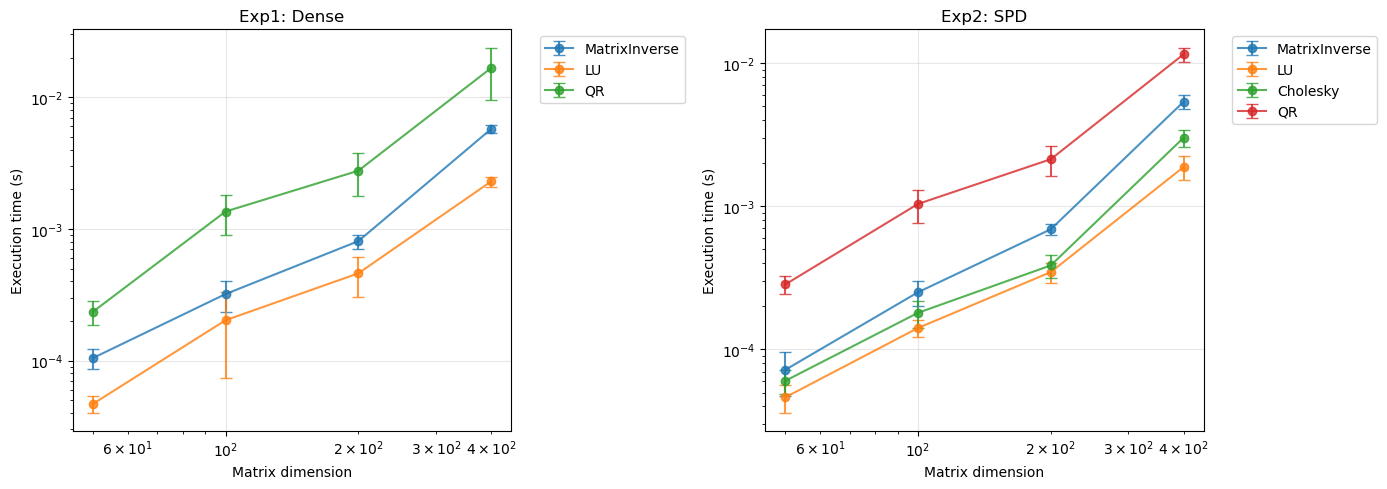

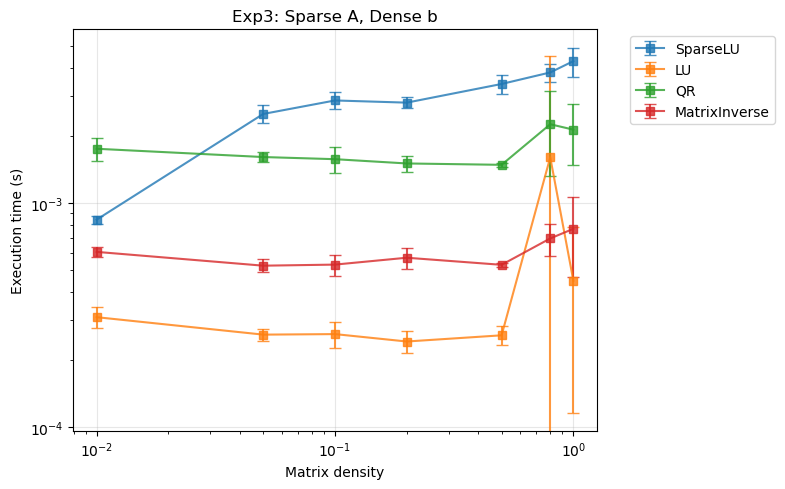

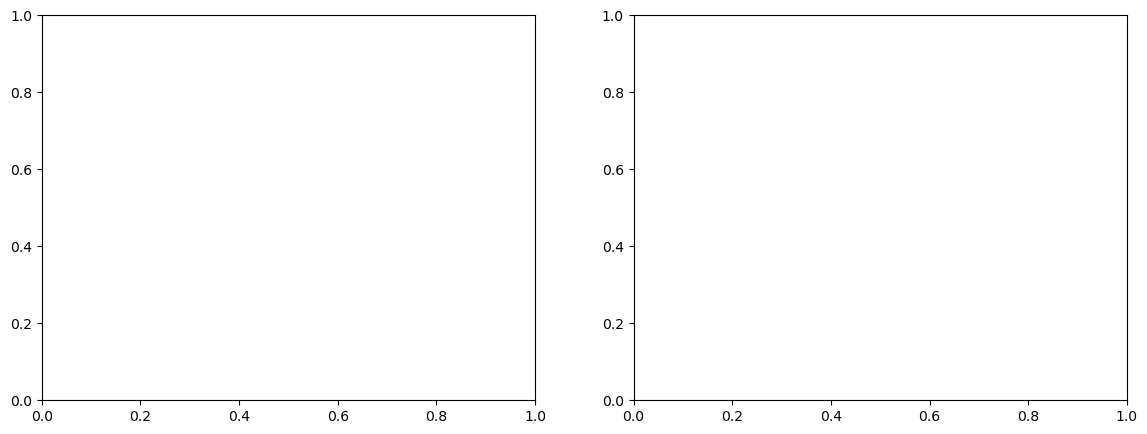

In [181]:
create_plots(combined_results)
